In [40]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

In [41]:
# Загрузка данных
X = pd.read_excel('X_data.xlsx')
df_y = pd.read_excel('Y_data.xlsx')

# вычисление медианного значения CC50
median_cc50 = df_y['CC50, mM'].median()

# создание бинарной целевой переменной на основе медианного значения CC50
y = (df_y['CC50, mM'] > median_cc50).astype(int)

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [63]:
# Decision Tree Classifier для предсказания исходного CC50 > медианного значения на основе молекулярных дескрипторов

# Создание и обучение модели
clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)

clf.fit(X_train, y_train)

# Предсказывание на тестовой выборке
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

# oценка точности модели
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob) 

print("Отчет о классификации Decision Tree:")
print(classification_report(y_test, y_pred))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f'Точность модели: {accuracy:.2f}')
print(f'ROC AUC модели: {roc_auc:.2f}') 

Отчет о классификации Decision Tree:
              precision    recall  f1-score   support

           0       0.79      0.45      0.57       100
           1       0.62      0.88      0.72       100

    accuracy                           0.67       200
   macro avg       0.70      0.67      0.65       200
weighted avg       0.70      0.67      0.65       200

Матрица ошибок:
[[45 55]
 [12 88]]
Точность модели: 0.67
ROC AUC модели: 0.73


##### Вывод: 
Модель DecisionTreeClassifier показала умеренное качество классификации (Accuracy ≈ 0.67, ROC-AUC ≈ 0.73). При этом наблюдался выраженный дисбаланс качества распознавания классов: модель значительно лучше определяла класс 1 (recall ≈ 0.88), чем класс 0 (recall ≈ 0.45).

Матрица ошибок показывает, что модель склонна к предсказанию положительного класса, что приводит к большому числу ложноположительных результатов для класса 0. Это может свидетельствовать о недостаточной способности одиночного дерева решений к устойчивому разделению классов в данной задачe.



In [62]:
# Настройка гиперпараметров для Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 3, 5, 7, 10, 15],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=50,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

# Вывод лучших параметров и результатов кросс-валидации
print("Best params:", search.best_params_)
print("Best CV ROC-AUC:", search.best_score_)

# Получение лучшей модели
best_rf = search.best_estimator_

# Предсказывание на тестовой выборке
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

# oценка точности модели
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob) 

print("Отчет о классификации Random Forest:")
print(classification_report(y_test, y_pred))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f'Точность модели: {accuracy:.2f}')
print(f'ROC AUC модели: {roc_auc:.2f}') 

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'n_estimators': 300, 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': True}
Best CV ROC-AUC: 0.8434173259493672
Отчет о классификации Random Forest:
              precision    recall  f1-score   support

           0       0.76      0.71      0.74       100
           1       0.73      0.78      0.75       100

    accuracy                           0.74       200
   macro avg       0.75      0.74      0.74       200
weighted avg       0.75      0.74      0.74       200

Матрица ошибок:
[[71 29]
 [22 78]]
Точность модели: 0.74
ROC AUC модели: 0.84


##### Вывод:
Для повышения устойчивости модели и уменьшения переобучения был использован RandomForestClassifier, представляющий собой ансамбль деревьев решений. В отличие от одиночного дерева, случайный лес обучает большое количество деревьев на различных подвыборках данных и усредняет их предсказания, что позволяет повысить качество классификации и устойчивость модели к шуму и особенностям обучающей выборки. Подбор гиперпараметров осуществлялся с помощью RandomizedSearchCV и кросс-валидации (cv=5).

По сравнению с одиночным деревом решений RandomForestClassifier продемонстрировал более высокое качество классификации (Accuracy ≈ 0.74, ROC-AUC ≈ 0.84). Модель обеспечила более сбалансированное распознавание обоих классов и снизила количество ошибок классификации, что подтверждается улучшением значений precision, recall и F1-score. Полученные результаты свидетельствуют о том, что ансамбли деревьев лучше подходят для решения задач классификации СC50 на основе молекулярных дескрипторов.

<Axes: title={'center': 'Важность признаков после обучения случайного леса'}, ylabel='Feature'>

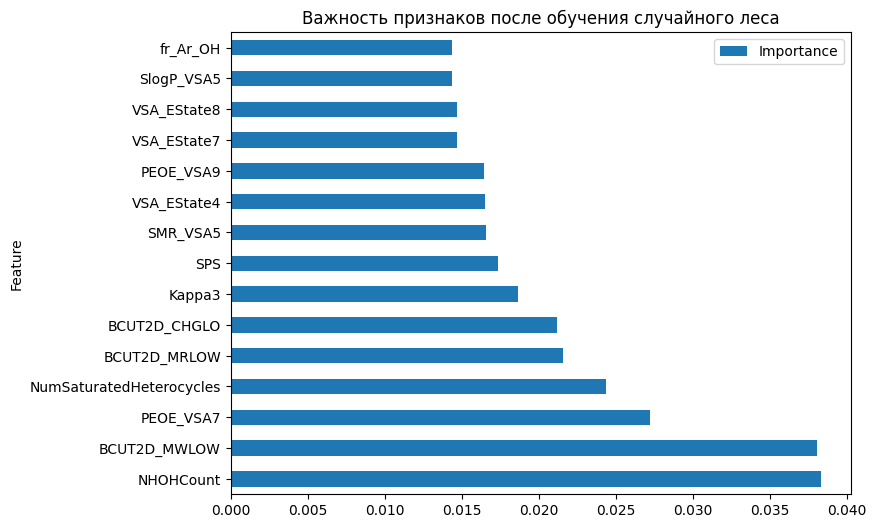

In [44]:
# визуализация важности признаков после обучения случайного леса
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

importance_df.head(15).plot.barh(
    x='Feature',
    y='Importance',
    figsize=(8,6),
    title='Важность признаков после обучения случайного леса'
)


Анализ важности признаков RandomForestClassifier показал, что наибольший вклад в разделение классов по CC50 вносят дескрипторы, характеризующие электронные свойства, распределение зарядов и структурные особенности молекул.

Среди наиболее значимых признаков модель выделила BCUT2D_MWLOW, NHOHCount, PEOE_VSA7, NumSaturatedHeterocycles, BCUT2D_MRLOW и BCUT2D_CHGLO. Это указывает на важную роль молекулярной массы, распределения электронной плотности, наличия гидроксильных/аминных групп и особенностей гетероциклической структуры в определении токсичности соединений.

Высокая важность дескрипторов Kappa3, SPS, VSA_EState* и SMR_VSA5 также свидетельствует о значительном влиянии топологических и физико-химических свойств молекулы на вероятность отнесения соединения к различным классам токсичности.

Полученные результаты подтверждают, что задача классификации CC50 определяется совокупностью структурных, электронных и топологических характеристик молекул, а ансамблевые методы позволяют эффективно выявлять наиболее информативные дескрипторы для разделения классов.


In [59]:
# Логистическая регрессия для предсказания исходного CC50 > медианного значения на основе молекулярных дескрипторов
# параметры модели: L1-регуляризация, solver='liblinear', max_iter=10000, random_state=42

# cоздание и обучение модели
model_l1 = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=10000,
    random_state=42
)

model_l1.fit(X_train, y_train)

# предсказывание на тестовой выборке
y_pred = model_l1.predict(X_test)
y_prob = model_l1.predict_proba(X_test)[:, 1]

# oценка точности модели
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob) 

print("Отчет о классификации Logistic Regression с L1-регуляризацией:")
print(classification_report(y_test, y_pred))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f'Точность модели: {accuracy:.2f}')
print(f'ROC AUC модели: {roc_auc:.2f}') 

Отчет о классификации Logistic Regression с L1-регуляризацией:
              precision    recall  f1-score   support

           0       0.76      0.68      0.72       100
           1       0.71      0.79      0.75       100

    accuracy                           0.73       200
   macro avg       0.74      0.74      0.73       200
weighted avg       0.74      0.73      0.73       200

Матрица ошибок:
[[68 32]
 [21 79]]
Точность модели: 0.73
ROC AUC модели: 0.82


In [60]:
# Логистическая регрессия для предсказания исходного CC50 > медианного значения на основе молекулярных дескрипторов
# параметры модели: L2-регуляризация, solver='liblinear', max_iter=50000, random_state=42

# cоздание и обучение модели
model_l2 = LogisticRegression(
    penalty='l2',
    solver='liblinear',
    max_iter=50000,
    random_state=42
)

model_l2.fit(X_train, y_train)

# предсказывание на тестовой выборке
y_pred = model_l2.predict(X_test)
y_prob = model_l2.predict_proba(X_test)[:, 1]

# oценка точности модели
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob) 

print("Отчет о классификации Logistic Regression с L2-регуляризацией:")
print(classification_report(y_test, y_pred))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f'Точность модели: {accuracy:.2f}')
print(f'ROC AUC модели: {roc_auc:.2f}') 

Отчет о классификации Logistic Regression с L2-регуляризацией:
              precision    recall  f1-score   support

           0       0.75      0.66      0.70       100
           1       0.70      0.78      0.74       100

    accuracy                           0.72       200
   macro avg       0.72      0.72      0.72       200
weighted avg       0.72      0.72      0.72       200

Матрица ошибок:
[[66 34]
 [22 78]]
Точность модели: 0.72
ROC AUC модели: 0.82


##### Вывод:

Модель LogisticRegression с L1-регуляризацией показала хорошее качество классификации (Accuracy ≈ 0.73, ROC-AUC ≈ 0.82)
Использование L1-регуляризации позволило уменьшить влияние мультиколлинеарности и автоматически отобрать наиболее информативные молекулярные дескрипторы, что особенно важно при работе с высокоразмерными QSAR-данными.) и продемонстрировала более сбалансированное распознавание классов по сравнению с одиночным деревом решений.


Сравнение L1- и L2-регуляризации показало, что L1-регуляризация обеспечивает немного более высокое качество классификации (Accuracy ≈ 0.73, ROC-AUC ≈ 0.82) по сравнению с L2-регуляризацией (Accuracy ≈ 0.72, ROC-AUC ≈ 0.82).

Полученные результаты свидетельствуют о том, что для данной QSAR-задачи feature selection играет важную роль. Использование L1-регуляризации позволило уменьшить влияние избыточных и коррелированных молекулярных дескрипторов, что привело к более эффективному разделению классов. 

При этом обе модели показали сопоставимое качество классификации, что указывает на наличие достаточно устойчивых линейных закономерностей между молекулярными дескрипторами и принадлежностью соединений к различным классам активности/токсичности.

In [56]:
# CatBoost Classifier для предсказания исходного CC50 > медианного значения на основе молекулярных дескрипторов

# Создание и обучение модели
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_state=42,
    verbose=0
)

model.fit(X_train, y_train)

# Предсказывание на тестовой выборке
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# oценка точности модели
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob) 

print("Отчет о классификации CatBoost:")
print(classification_report(y_test, y_pred))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f'Точность модели: {accuracy:.2f}')
print(f'ROC AUC модели: {roc_auc:.2f}') 

Отчет о классификации CatBoost:
              precision    recall  f1-score   support

           0       0.77      0.72      0.75       100
           1       0.74      0.79      0.76       100

    accuracy                           0.76       200
   macro avg       0.76      0.76      0.75       200
weighted avg       0.76      0.76      0.75       200

Матрица ошибок:
[[72 28]
 [21 79]]
Точность модели: 0.76
ROC AUC модели: 0.86


##### Вывод:

Модель CatBoostClassifier показала наилучшее качество классификации среди исследованных моделей (Accuracy ≈ 0.76, ROC-AUC ≈ 0.86) и обеспечила наиболее сбалансированное распознавание обоих классов.

По сравнению с линейными моделями и одиночным деревом решений CatBoostClassifier лучше справился с выявлением сложных нелинейных зависимостей между молекулярными дескрипторами и принадлежностью соединений к различным классам активности/токсичности.

Полученные результаты подтверждают эффективность ансамблевых boosting-моделей для решения QSAR-задач, содержащих большое количество взаимосвязанных молекулярных дескрипторов и сложные нелинейные закономерности.

Несмотря на улучшение качества классификации по сравнению с другими моделями, полученные значения ROC-AUC остаются умеренными, что указывает на высокую сложность задачи и вероятное влияние дополнительных факторов, не полностью описываемых используемыми молекулярными дескрипторами.

<Axes: title={'center': 'Важность признаков после обучения CatBoost'}, ylabel='Feature'>

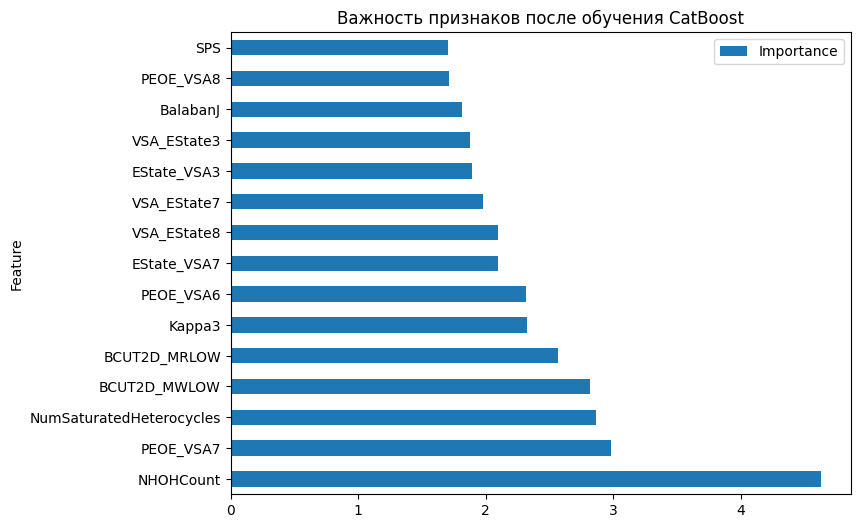

In [48]:
# визуализация важности признаков после обучения CatBoost
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

importance_df.head(15).plot.barh(
    x='Feature',
    y='Importance',
    figsize=(8,6),
    title='Важность признаков после обучения CatBoost'
)


Анализ важности признаков CatBoostClassifier показал, что наибольший вклад в разделение классов по CC50 вносят дескрипторы, характеризующие электронные свойства, топологическую структуру и физико-химические характеристики молекул.

Среди наиболее значимых признаков модель выделила NHOHCount, PEOE_VSA7, BCUT2D_MWLOW, NumSaturatedHeterocycles, BCUT2D_MRLOW, EState_VSA7 и Kappa3. Это указывает на важную роль распределения электронной плотности, наличия функциональных групп, особенностей гетероциклической структуры и топологической сложности молекул в определении принадлежности соединений к различным классам токсичности.

Высокая важность дескрипторов MolLogP, VSA_EState*, PEOE_VSA6 и FpDensityMorgan3 также свидетельствует о значительном влиянии липофильности, электронных характеристик и структурных фрагментов молекулы на результаты классификации.

Полученные результаты хорошо согласуются с выводами моделей RandomForestClassifier и логистической регрессии, подтверждая устойчивую значимость топологических, электронных и физико-химических дескрипторов для решения QSAR-задачи классификации CC50.


In [61]:
# SVM Classifier  для предсказания исходного CC50 > медианного значения на основе молекулярных дескрипторов

# стандартизация данных
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Создание и обучение модели
model = SVC(kernel='rbf', C=1, gamma='scale')
model.fit(X_train, y_train)

# Предсказание на тестовой выборке
y_pred = model.predict(X_test)
y_prob = model.decision_function(X_test)

# oценка точности модели
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob) 

print("Отчет о классификации SVM:")
print(classification_report(y_test, y_pred))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f'Точность модели: {accuracy:.2f}')
print(f'ROC AUC модели: {roc_auc:.2f}') 

Отчет о классификации SVM:
              precision    recall  f1-score   support

           0       0.76      0.71      0.73       100
           1       0.73      0.77      0.75       100

    accuracy                           0.74       200
   macro avg       0.74      0.74      0.74       200
weighted avg       0.74      0.74      0.74       200

Матрица ошибок:
[[71 29]
 [23 77]]
Точность модели: 0.74
ROC AUC модели: 0.83


In [52]:
# Настройка гиперпараметров для SVM Classifier с использованием GridSearchCV

# Создание пайплайна для стандартизации данных и обучения модели SVM
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', probability=True, random_state=42))
])

# Определение сетки гиперпараметров для поиска
param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': ['scale', 0.1, 0.01, 0.001]
}

# Настройка GridSearchCV для поиска лучших гиперпараметров
grid = GridSearchCV(
    pipe,
    param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Обучение модели с использованием GridSearchCV
grid.fit(X_train, y_train)

# Вывод лучших параметров и результатов кросс-валидации
print("Best params:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

# Получение лучшей модели
best_svm = grid.best_estimator_

# Предсказывание на тестовой выборке с использованием лучшей модели
y_pred = best_svm.predict(X_test)
y_prob = best_svm.predict_proba(X_test)[:, 1]

# oценка точности модели
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob) 

print("Отчет о классификации SVM:")
print(classification_report(y_test, y_pred))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f'Точность модели: {accuracy:.2f}')
print(f'ROC AUC модели: {roc_auc:.2f}') 

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'svc__C': 1, 'svc__gamma': 'scale'}
Best CV ROC-AUC: 0.8392124208860758
Отчет о классификации SVM:
              precision    recall  f1-score   support

           0       0.76      0.71      0.73       100
           1       0.73      0.77      0.75       100

    accuracy                           0.74       200
   macro avg       0.74      0.74      0.74       200
weighted avg       0.74      0.74      0.74       200

Матрица ошибок:
[[71 29]
 [23 77]]
Точность модели: 0.74
ROC AUC модели: 0.83


Для моделирования нелинейных зависимостей между молекулярными дескрипторами и принадлежностью соединений к различным классам была использована модель SVM (Support Vector Machine) с RBF-ядром. Поскольку метод опорных векторов чувствителен к масштабу признаков, перед обучением модели была выполнена стандартизация данных. 

Базовая модель SVM показала хорошее качество классификации (Accuracy ≈ 0.74, ROC-AUC ≈ 0.83) и обеспечила достаточно сбалансированное распознавание обоих классов. Полученные результаты свидетельствуют о способности SVM эффективно выявлять сложные нелинейные закономерности между молекулярными дескрипторами и исследуемыми классами соединений.

Для подбора оптимальных гиперпараметров SVM использовался GridSearchCV с кросс-валидацией (cv=5). По результатам поиска наилучшей комбинацией параметров оказались C = 1 и gamma = 'scale', что совпало с параметрами модели по умолчанию. Это свидетельствует о том, что исходная конфигурация SVM уже обеспечивала близкое к оптимальному качество классификации для данной QSAR-задачи.

Высокое значение ROC-AUC указывает на хорошую способность модели разделять классы даже при умеренных значениях accuracy, что особенно важно для QSAR-задач классификации.

#### Вывод:

В ходе работы были исследованы различные подходы к классификации соединений по CC50 на основе молекулярных дескрипторов. Были рассмотрены линейные и нелинейные модели машинного обучения, включая LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, SVM и CatBoostClassifier.

Сравнение линейных моделей показало, что LogisticRegression с L1-регуляризацией обеспечивает немного более высокое качество классификации по сравнению с L2-регуляризацией. Использование L1-регуляризации позволило уменьшить влияние мультиколлинеарности и автоматически отобрать наиболее информативные молекулярные дескрипторы, что особенно важно при работе с высокоразмерными QSAR-данными.

Одиночное дерево решений показало ограниченное качество классификации и склонность к переобучению. Использование ансамблевых методов (RandomForestClassifier и CatBoostClassifier) позволило повысить устойчивость моделей и улучшить качество разделения классов за счёт более эффективного моделирования сложных нелинейных зависимостей между молекулярными дескрипторами и токсичностью соединений.

Модель SVM с RBF-ядром также продемонстрировала высокое качество классификации (ROC-AUC ≈ 0.83), что свидетельствует о способности kernel-методов эффективно выявлять сложные нелинейные закономерности в QSAR-данных.

Наилучшее качество классификации среди исследованных моделей показал CatBoostClassifier (Accuracy ≈ 0.76, ROC-AUC ≈ 0.86), обеспечив наиболее сбалансированное распознавание обоих классов. При этом высокое значение ROC-AUC для SVM указывает на хорошую способность модели разделять классы на уровне вероятностей.

Анализ важности признаков показал, что наибольший вклад в классификацию CC50 вносят дескрипторы, характеризующие электронные, топологические и физико-химические свойства молекул. Полученные результаты подтверждают, что токсичность соединений определяется совокупностью структурных и электронных характеристик молекулы.

Несмотря на использование различных методов машинного обучения, качество классификации оказалось умеренным, что указывает на высокую сложность QSAR-задачи и вероятное влияние дополнительных факторов, не полностью описываемых используемыми молекулярными дескрипторами.
